# How to use a MatGL TensorNet model to select structures from a `pool_set`

This notebook explains one concrete path only:

1. load a MatGL model inside CURATOR,
2. inspect the adapter and the target layer used for feature extraction,
3. build `GeneralActiveLearning`,
4. select structures from a single `pool_set`,
5. visualize the selected structures in UMAP space.

The example model is MatGL TensorNet:
`matgl:TensorNet-MatPES-PBE-v2025.1-PES`


## What you need to change

In normal use, the only thing you should change is `pool_set`.

Everything else below is just the selection recipe:

- model: `TensorNet-MatPES-PBE-v2025.1-PES`
- kernel: `full-g`
- method: `lcmd_greedy`
- target layer: `final_layer`
- random feature size: `256`


In [14]:
from pathlib import Path

# Change only this path.
pool_set = Path('../example/LiFePO4.traj').resolve()
assert pool_set.exists(), f'pool_set does not exist: {pool_set}'

run_dir = Path('./runs/matgl_tensornet_select_demo').resolve()
run_dir.mkdir(parents=True, exist_ok=True)

pool_set, run_dir


(PosixPath('/home/xinyang/curator-pre_release/example/LiFePO4.traj'),
 PosixPath('/home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo'))

## Imports

`load_models(...)` is the key entry point.
When CURATOR sees a string that starts with `matgl:`, it loads the MatGL model and wraps it in a CURATOR-compatible adapter.


In [15]:
import inspect
import json
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from ase.io import read
from pytorch_lightning import seed_everything
from umap import UMAP

from curator.layer._feature import FeatureExtractor
from curator.layer.utils import find_layer_by_name_recursive
from curator.select import GeneralActiveLearning
from curator.utils import load_models

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
seed_everything(123, workers=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


Seed set to 123


'cuda'

## 1. Load the MatGL model

This is the exact idea used by `curator-select`:

- pass a `model_path` string,
- let `load_models(...)` decide how to load it,
- get back a CURATOR model object.

For a MatGL model, the returned object is a `MatGLAdapter`, not the raw MatGL model.


In [16]:
model = load_models(
    'matgl:TensorNet-MatPES-PBE-v2025.1-PES',
    device=device,
    load_compiled=False,
)[0]

{
    'loaded_object': model.__class__.__name__,
    'wrapped_core_model': model.core_model.__class__.__name__,
    'backend': model.backend,
    'cutoff': model.representation.cutoff,
    'device': device,
    'load_models_source': inspect.getfile(load_models),
    'adapter_source': inspect.getfile(model.__class__),
}


{'loaded_object': 'MatGLAdapter',
 'wrapped_core_model': 'TensorNet',
 'backend': 'PYG',
 'cutoff': 5.0,
 'device': 'cuda',
 'load_models_source': '/home/xinyang/curator-pre_release/curator/utils.py',
 'adapter_source': '/home/xinyang/curator-pre_release/curator/model/adapters.py'}

## 2. Check the target layer used by selection

For this TensorNet example, selection uses `target_layer='final_layer'`.

That matters because `FeatureExtractor` will attach hooks under this module and collect the features and gradients used by the selection kernel.


In [17]:
target_layer = 'final_layer'
target_module = find_layer_by_name_recursive(model, target_layer)
linear_types = FeatureExtractor._resolve_linear_types()
linear_modules = [
    (name, child.__class__.__name__)
    for name, child in target_module.named_modules()
    if isinstance(child, linear_types)
]

print('target layer name:', target_layer)
print('resolved module class:', target_module.__class__.__name__)
print('number of linear-like submodules:', len(linear_modules))
linear_modules[:8]


target layer name: final_layer
resolved module class: WeightedReadOut
number of linear-like submodules: 8


[('gated.layers.0', 'Linear'),
 ('gated.layers.2', 'Linear'),
 ('gated.layers.4', 'Linear'),
 ('gated.layers.6', 'Linear'),
 ('gated.gates.0', 'Linear'),
 ('gated.gates.2', 'Linear'),
 ('gated.gates.4', 'Linear'),
 ('gated.gates.6', 'Linear')]

## 3. See how one structure from `pool_set` becomes a MatGL graph

`MatGLAdapter` converts ASE atoms into the graph objects expected by MatGL.
This is the bridge between CURATOR's dataset pipeline and the MatGL model.


In [18]:
atoms = read(pool_set, index=0)
graph, lat, state_attr = model.graph_converter.get_graph(atoms)

num_nodes = graph.num_nodes if not callable(getattr(graph, 'num_nodes', None)) else graph.num_nodes()
try:
    num_edges = graph.num_edges if not callable(getattr(graph, 'num_edges', None)) else graph.num_edges()
except Exception:
    num_edges = int(graph.edge_index.shape[1])

{
    'formula': atoms.get_chemical_formula(),
    'num_atoms': len(atoms),
    'pbc': tuple(bool(x) for x in atoms.pbc),
    'graph_class': graph.__class__.__name__,
    'graph_nodes': num_nodes,
    'graph_edges': num_edges,
    'lat_shape': tuple(lat.shape),
    'state_attr_shape': tuple(state_attr.shape),
}


{'formula': 'Fe4Li4O16P4',
 'num_atoms': 28,
 'pbc': (True, True, True),
 'graph_class': 'Data',
 'graph_nodes': 28,
 'graph_edges': 1112,
 'lat_shape': (1, 3, 3),
 'state_attr_shape': (2,)}

## 4. Build the active-learning object

This object is what actually drives structure selection.

Important arguments here:

- `models=[model]`: use the MatGL TensorNet adapter
- `kernel='full-g'`: use gradient-based random features
- `selection='lcmd_greedy'`: use LCMD greedy selection
- `target_layer='final_layer'`: extract features from TensorNet's final readout layer
- `save_features=...`: store the features so they can be visualized later


In [19]:
features_h5 = run_dir / 'features.h5'

al = GeneralActiveLearning(
    models=[model],
    kernel='full-g',
    kernels=None,
    selection='lcmd_greedy',
    n_random_features=256,
    target_layer='final_layer',
    batch_size=4,
    device=device,
    dataset_cutoff=model.representation.cutoff,
    transforms=[],
    save_features=str(features_h5),
    target_domain=None,
)

{
    'selection_engine': al.__class__.__name__,
    'selection_engine_source': inspect.getfile(GeneralActiveLearning),
    'kernel': al.kernel,
    'selection_method': al.selection,
    'target_layer': al.target_layer,
    'batch_size': al.batch_size,
    'dataset_cutoff': al.dataset_cutoff,
    'features_h5': str(features_h5),
}


{'selection_engine': 'GeneralActiveLearning',
 'selection_engine_source': '/home/xinyang/curator-pre_release/curator/select/active_learning.py',
 'kernel': 'full-g',
 'selection_method': 'lcmd_greedy',
 'target_layer': 'final_layer',
 'batch_size': 4,
 'dataset_cutoff': 5.0,
 'features_h5': '/home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo/features.h5'}

## 5. Select structures from `pool_set`

This is the core call.

If your `pool_set` is large, this may take some time. For a first test, you can lower `select_batch_size`.
The selected indices are written to `selected.json`.


In [20]:
selected = al.select(
    pool_set=str(pool_set),
    train_set=None,
    select_batch_size=100,
    save_json=str(run_dir / 'selected.json'),
    save_images=None,
    save_selected_features=None,
    normalize_features=True,
    compute_features_only=False,
)

print('number of selected structures:', len(selected))
print('first ten selected indices:', selected[:10])


model=MatGLAdapter kernels=1 size=2257 bs=4:   0%|          | 0/565 [00:00<?, ?it/s]

number of selected structures: 100
first ten selected indices: [2153, 430, 2256, 1211, 2018, 5, 2063, 1429, 2130, 2112]


In [21]:
json.loads((run_dir / 'selected.json').read_text())


{'kernel': 'full-g',
 'selection': 'lcmd_greedy',
 'dataset': {'pool': '/home/xinyang/curator-pre_release/example/LiFePO4.traj',
  'train': None},
 'selected': [2153,
  430,
  2256,
  1211,
  2018,
  5,
  2063,
  1429,
  2130,
  2112,
  1854,
  1289,
  1595,
  1976,
  1370,
  1517,
  1583,
  699,
  1641,
  1225,
  1724,
  1205,
  1622,
  1360,
  1340,
  1256,
  1092,
  1187,
  659,
  1181,
  189,
  1044,
  968,
  2087,
  2180,
  2218,
  1842,
  2235,
  2041,
  2096,
  2143,
  1911,
  1890,
  1960,
  2199,
  1497,
  915,
  1170,
  2123,
  168,
  1825,
  2210,
  873,
  844,
  796,
  1315,
  2174,
  1672,
  1220,
  450,
  941,
  1418,
  1385,
  1164,
  479,
  1847,
  2034,
  2070,
  1882,
  1987,
  1833,
  228,
  60,
  1681,
  1791,
  2049,
  1744,
  1439,
  808,
  1100,
  549,
  2160,
  1071,
  726,
  1936,
  646,
  1156,
  959,
  501,
  2027,
  2007,
  1602,
  1265,
  1945,
  1249,
  597,
  377,
  1507,
  1631,
  1274],
 'summary': {'count': 100,
  'filter_enabled': False,
  'pool_size_

## 6. Visualize the selection in UMAP space

The plotting logic below is adapted from:
`/home/xinyang/curator/runs/select_matgl_compare/plot_selection_umap_with_aef.py`

The idea is:

1. load the saved `full-gradient` features from `features.h5`,
2. reduce them to 2D with UMAP,
3. overlay the CURATOR `lcmd_greedy` selection,
4. build a simple baseline that selects the structures with the largest AE-F,
5. compare both selections on the same figure,
6. if reference forces are available in `pool_set`, color the background by AE-F
   (mean absolute force error).

AE-F needs reference forces inside the structures in `pool_set`.
If they are not available, the notebook will still make a UMAP plot, but the
`max AE-F` comparison will not be available.


In [22]:
def read_selected(path: Path) -> np.ndarray:
    with path.open('r', encoding='utf-8') as handle:
        return np.asarray(json.load(handle)['selected'], dtype=int)


def has_reference_forces(path: Path) -> bool:
    sample = read(path, index=0)
    try:
        sample.get_forces(apply_constraint=False)
        return True
    except Exception:
        return False


def compute_aef_from_adapter(model, pool_set: Path, batch_size: int = 8) -> np.ndarray:
    atoms_list = read(str(pool_set), ':')
    aef = np.zeros((len(atoms_list),), dtype=np.float64)

    for start in range(0, len(atoms_list), batch_size):
        batch = atoms_list[start : start + batch_size]
        n_atoms = [len(atoms) for atoms in batch]
        g, lat, state = model._batch_graphs(batch)
        g = g.to(device)
        lat = lat.to(device)
        state = state.to(device)

        out = model.potential(g=g, lat=lat, state_attr=state)
        if not isinstance(out, tuple) or len(out) < 2:
            raise RuntimeError('MatGL potential output does not include force predictions.')
        force_pred = out[1].detach().cpu().numpy()

        offset = 0
        for i, atoms in enumerate(batch):
            n = n_atoms[i]
            fp = force_pred[offset : offset + n]
            ft = atoms.get_forces(apply_constraint=False)
            aef[start + i] = float(np.mean(np.abs(fp - ft)))
            offset += n

    return aef


In [23]:
feature_key = 'full-gradient'
lcmd_idx = read_selected(run_dir / 'selected.json')

with h5py.File(features_h5, 'r') as handle:
    features = handle[f'features/{feature_key}/data'][0]

embedding = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.12,
    metric='cosine',
    random_state=42,
).fit_transform(features)

aef = None
max_aef_idx = None
overlap_idx = None
only_lcmd_idx = None
only_aef_idx = None
if has_reference_forces(pool_set):
    aef = compute_aef_from_adapter(model, pool_set=pool_set, batch_size=8)
    max_aef_idx = np.argsort(aef)[-len(lcmd_idx):]
    lcmd_set = set(lcmd_idx.tolist())
    max_aef_set = set(max_aef_idx.tolist())
    overlap_idx = np.array(sorted(lcmd_set & max_aef_set), dtype=int)
    only_lcmd_idx = np.array(sorted(lcmd_set - max_aef_set), dtype=int)
    only_aef_idx = np.array(sorted(max_aef_set - lcmd_set), dtype=int)

print('features shape:', features.shape)
print('embedding shape:', embedding.shape)
print('has AE-F:', aef is not None)
if aef is not None:
    print('LCMD count:', len(lcmd_idx))
    print('max-AE-F count:', len(max_aef_idx))
    print('overlap count:', len(overlap_idx))


/home/xinyang/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


features shape: (2257, 256)
embedding shape: (2257, 2)
has AE-F: True
LCMD count: 100
max-AE-F count: 100
overlap count: 9


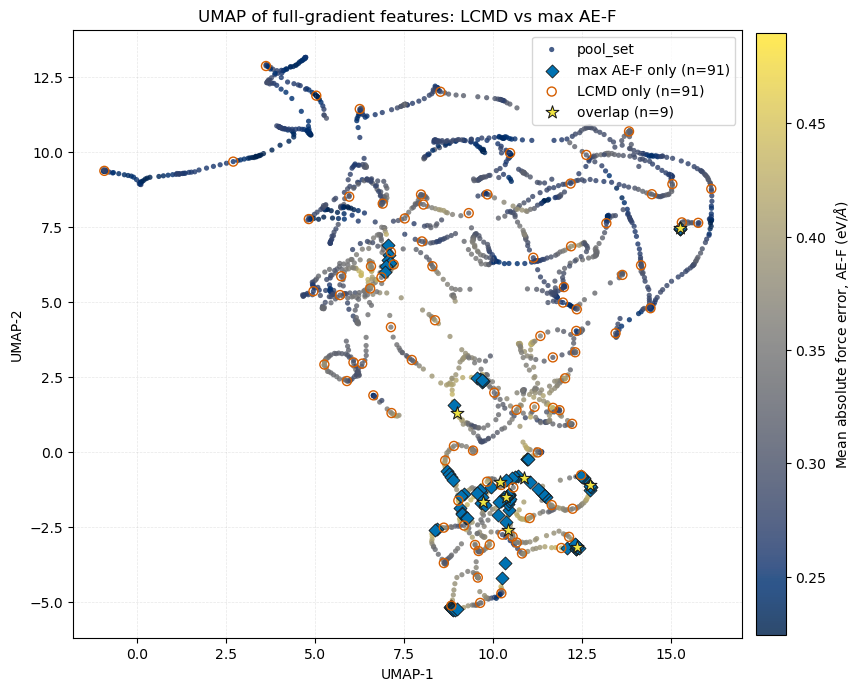

saved: /home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo/umap_lcmd_vs_max_aef.png
saved: /home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo/umap_lcmd_vs_max_aef.pdf


In [24]:
fig, ax = plt.subplots(figsize=(8.5, 6.8), constrained_layout=True)

color_lcmd_only = '#D55E00'
color_max_aef_only = '#0072B2'
color_overlap = '#F0E442'
color_edge = '#1A1A1A'

if aef is None:
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=14,
        c='#B8BDC7',
        alpha=0.65,
        linewidths=0,
        rasterized=True,
        label='pool_set',
    )
else:
    vmin = float(np.percentile(aef, 1.0))
    vmax = float(max(np.percentile(aef, 99.0), vmin + 1e-12))
    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=aef,
        cmap='cividis',
        s=14,
        alpha=0.82,
        linewidths=0,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
        label='pool_set',
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.045)
    cbar.set_label(r'Mean absolute force error, AE-F (eV/$\AA$)')

if aef is None:
    ax.scatter(
        embedding[lcmd_idx, 0],
        embedding[lcmd_idx, 1],
        s=42,
        facecolors='none',
        edgecolors=color_lcmd_only,
        linewidths=1.0,
        marker='o',
        zorder=5,
        label=f'LCMD selected (n={len(lcmd_idx)})',
    )
    ax.set_title('UMAP of full-gradient features with LCMD selection')
else:
    if len(only_aef_idx) > 0:
        ax.scatter(
            embedding[only_aef_idx, 0],
            embedding[only_aef_idx, 1],
            s=44,
            c=color_max_aef_only,
            edgecolors=color_edge,
            linewidths=0.6,
            marker='D',
            zorder=5,
            label=f'max AE-F only (n={len(only_aef_idx)})',
        )
    if len(only_lcmd_idx) > 0:
        ax.scatter(
            embedding[only_lcmd_idx, 0],
            embedding[only_lcmd_idx, 1],
            s=42,
            facecolors='none',
            edgecolors=color_lcmd_only,
            linewidths=1.0,
            marker='o',
            zorder=6,
            label=f'LCMD only (n={len(only_lcmd_idx)})',
        )
    if len(overlap_idx) > 0:
        ax.scatter(
            embedding[overlap_idx, 0],
            embedding[overlap_idx, 1],
            s=95,
            c=color_overlap,
            edgecolors=color_edge,
            linewidths=0.75,
            marker='*',
            zorder=7,
            label=f'overlap (n={len(overlap_idx)})',
        )
    ax.set_title('UMAP of full-gradient features: LCMD vs max AE-F')

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.legend(loc='best')

plot_png = run_dir / 'umap_lcmd_vs_max_aef.png'
plot_pdf = run_dir / 'umap_lcmd_vs_max_aef.pdf'
fig.savefig(plot_png, dpi=300, bbox_inches='tight')
fig.savefig(plot_pdf, dpi=300, bbox_inches='tight')
plt.show()

print('saved:', plot_png)
print('saved:', plot_pdf)


## 7. A complete `curator-select` YAML config for a MatGL model

If you do not want to build `GeneralActiveLearning(...)` manually in Python, you can do the same job with a normal `curator-select` YAML file.

This is the complete config pattern you need for MatGL TensorNet selection.


In [25]:
yaml_text = f"""_convert_: all
cfg: null
seed: 123
run_path: {run_dir}
model_path: matgl:TensorNet-MatPES-PBE-v2025.1-PES
device: {device}
train_set: null
pool_set: {pool_set}
data_url: null
data_batch_size: 4
select_batch_size: 100
kernel: full-g
export_kernels: null
method: lcmd_greedy
n_random_features: 256
target_layer: final_layer
save_features: true
save_selected_features: null
export_normalized_features: true
save_images: false
compute_features_only: false
target_domain: null
transforms: []
"""

print(yaml_text)


_convert_: all
cfg: null
seed: 123
run_path: /home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo
model_path: matgl:TensorNet-MatPES-PBE-v2025.1-PES
device: cuda
train_set: null
pool_set: /home/xinyang/curator-pre_release/example/LiFePO4.traj
data_url: null
data_batch_size: 4
select_batch_size: 100
kernel: full-g
export_kernels: null
method: lcmd_greedy
n_random_features: 256
target_layer: final_layer
save_features: true
save_selected_features: null
export_normalized_features: true
save_images: false
compute_features_only: false
target_domain: null
transforms: []



In [26]:
yaml_path = run_dir / 'select_matgl_tensornet.yaml'
yaml_path.write_text(yaml_text, encoding='utf-8')

print('saved:', yaml_path)
print()
print('Run this from a shell:')
print(f'curator-select cfg={yaml_path}')


saved: /home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo/select_matgl_tensornet.yaml

Run this from a shell:
curator-select cfg=/home/xinyang/curator-pre_release/notebooks/runs/matgl_tensornet_select_demo/select_matgl_tensornet.yaml


That YAML is enough to use a MatGL model for pool selection in CURATOR.

The two most important lines are:

- `model_path: matgl:TensorNet-MatPES-PBE-v2025.1-PES`
- `target_layer: final_layer`

The first tells CURATOR to load an external MatGL model through the adapter.
The second tells CURATOR where to attach hooks for feature extraction.
